In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [82]:
df1 = pd.read_csv("../gui_output/A153814/A153814_pole_scan_results.csv")
df1
df2 = pd.read_csv("../gui_output/A153814/A153814_pole_scan_results_wAtlas.csv")
df2

,index,initial_lambda,initial_beta,status,chi_square,dev,shadow_percent,fitted_lambda,fitted_beta,fitted_period,areas_file,lightcurve_output_file,param_file,stdout_log_file,error
0,0,347.764050,-88.188526,success,49.983060,0.189018,4.34,347.764050,-88.188526,4.2621,gui_output/A153814/pole_scan/run_0000/areas.txt,gui_output/A153814/pole_scan/run_0000/lc_outpu...,gui_output/A153814/pole_scan/run_0000/input_co...,gui_output/A153814/pole_scan/run_0000/convexin...,NaN
1,1,210.256286,-86.862173,success,46.125902,0.181578,1.40,210.256286,-86.862173,4.2621,gui_output/A153814/pole_scan/run_0001/areas.txt,gui_output/A153814/pole_scan/run_0001/lc_outpu...,gui_output/A153814/pole_scan/run_0001/input_co...,gui_output/A153814/pole_scan/run_0001/convexin...,NaN
2,2,72.748522,-85.948745,success,49.182996,0.187499,41.03,72.748522,-85.948745,4.2621,gui_output/A153814/pole_scan/run_0002/areas.txt,gui_output/A153814/pole_scan/run_0002/lc_outpu...,gui_output/A153814/pole_scan/run_0002/input_co...,gui_output/A153814/pole_scan/run_0002/convexin...,NaN
3,3,295.240758,-85.206091,success,48.702868,0.186581,2.46,295.240758,-85.206091,4.2621,gui_output/A153814/pole_scan/run_0003/areas.txt,gui_output/A153814/pole_scan/run_0003/lc_outpu...,gui_output/A153814/pole_scan/run_0003/input_co...,gui_output/A153814/pole_scan/run_0003/convexin...,NaN
4,4,157.732994,-84.563765,success,47.822739,0.184888,1.71,157.732994,-84.563765,4.2621,gui_output/A153814/pole_scan/run_0004/areas.txt,gui_output/A153814/pole_scan/run_0004/lc_outpu...,gui_output/A153814/pole_scan/run_0004/input_co...,gui_output/A153814/pole_scan/run_0004/convexin...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996,1996,202.267006,84.563765,success,53.072471,0.194772,18.16,202.267006,84.563765,4.2621,gui_output/A153814/pole_scan/run_1996/areas.txt,gui_output/A153814/pole_scan/run_1996/lc_outpu...,gui_output/A153814/pole_scan/run_1996/input_co...,gui_output/A153814/pole_scan/run_1996/convexin...,NaN
1997,1997,64.759242,85.206091,success,52.146093,0.193064,2.40,64.759242,85.206091,4.2621,gui_output/A153814/pole_scan/run_1997/areas.txt,gui_output/A153814/pole_scan/run_1997/lc_outpu...,gui_output/A153814/pole_scan/run_1997/input_co...,gui_output/A153814/pole_scan/run_1997/convexin...,NaN
1998,1998,287.251478,85.948745,success,54.441739,0.197268,14.46,287.251478,85.948745,4.2621,gui_output/A153814/pole_scan/run_1998/areas.txt,gui_output/A153814/pole_scan/run_1998/lc_outpu...,gui_output/A153814/pole_scan/run_1998/input_co...,gui_output/A153814/pole_scan/run_1998/convexin...,NaN
1999,1999,149.743714,86.862173,success,54.598846,0.197553,2.92,149.743714,86.862173,4.2621,gui_output/A153814/pole_scan/run_1999/areas.txt,gui_output/A153814/pole_scan/run_1999/lc_outpu...,gui_output/A153814/pole_scan/run_1999/input_co...,gui_output/A153814/pole_scan/run_1999/convexin...,NaN


In [96]:
xx1 = df1["initial_lambda"].values
yy1 = df1["initial_beta"].values
Z1_chi2 = df1["chi_square"].values

xx2 = df2["initial_lambda"].values
yy2 = df2["initial_beta"].values
Z2_chi2 = df2["chi_square"].values

In [97]:
def calc_CI_chi2(dof, sigma=3):
    """Calculate confidense interval (CI) of chi2 distribution.
    
    Parameters
    ----------
    dof : int, optional 
        degree of freedom of chi2 distribution (N-M)
    sigma : int
      confidence level

    Return
    ------
    CI : float
        n-sigma confidence interval in percentage
    """
    # For reduced chi2
    CI = sigma*(2/dof)**0.5
    return CI

# Assume nu = N - M ~ N (i.e., N >> M)
N = 1114
M = 50
dof = N - M
CI1 = calc_CI_chi2(dof, sigma=3.0)
print(f"3-sigma CI is {CI1:.2f}")
ch1 = np.min(Z1_chi2)
print(f"Minimum chi2 is {ch1:.2f}")
Z1_chi2 = Z1_chi2 / ch1
print(f"Minimum chi2 is {np.min(Z1_chi2):.2f}")


N = 1399
M = 50
dof = N - M
CI2 = calc_CI_chi2(dof, sigma=3.0)
print(f"3-sigma CI is {CI2:.2f}")
ch2 = np.min(Z2_chi2)
Z2_chi2 = Z2_chi2 / ch2
print(f"Minimum chi2 is {np.min(Z2_chi2):.2f}")

3-sigma CI is 0.13
Minimum chi2 is 1.08
Minimum chi2 is 1.00
3-sigma CI is 0.12
Minimum chi2 is 1.00


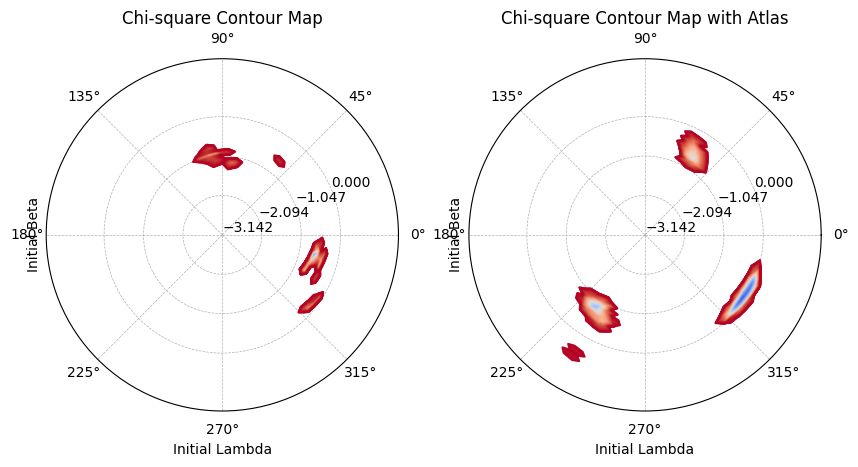

In [106]:
# Plot conturf map
k = 3

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(121, projection="polar")
plt.tricontour(np.deg2rad(xx1 - 0), np.deg2rad(yy1), 
                np.where(Z1_chi2 > 1 + CI1/k, 1 + CI1/k, Z1_chi2), levels=360, cmap="coolwarm")
# plt.colorbar(label="Chi-square")
ax.set_rticks(np.linspace(0, -np.pi, 4))
plt.xlabel("Initial Lambda")
plt.ylabel("Initial Beta")
plt.title("Chi-square Contour Map")
plt.grid(lw=0.5, ls="--")
# ax.set_rlim(0, -np.pi/2)

ax = fig.add_subplot(122, projection="polar")
plt.tricontour(np.deg2rad(xx2 - 0), np.deg2rad(yy2), 
                np.where(Z2_chi2 > 1 + CI2/k, 1 + CI2/k, Z2_chi2), levels=360, cmap="coolwarm")
# plt.colorbar(label="Chi-square")
ax.set_rticks(np.linspace(0, -np.pi, 4))
plt.xlabel("Initial Lambda")
plt.ylabel("Initial Beta")
plt.title("Chi-square Contour Map with Atlas")
plt.grid(lw=0.5, ls="--")
# ax.set_rlim(0, -np.pi/2)
plt.show()

In [74]:
df = pd.read_csv("../gui_output/A153814/A153814_pole_scan_results_wAtlas.csv")
df

,index,initial_lambda,initial_beta,status,chi_square,dev,shadow_percent,fitted_lambda,fitted_beta,fitted_period,areas_file,lightcurve_output_file,param_file,stdout_log_file,error
0,0,347.764050,-88.188526,success,49.983060,0.189018,4.34,347.764050,-88.188526,4.2621,gui_output/A153814/pole_scan/run_0000/areas.txt,gui_output/A153814/pole_scan/run_0000/lc_outpu...,gui_output/A153814/pole_scan/run_0000/input_co...,gui_output/A153814/pole_scan/run_0000/convexin...,NaN
1,1,210.256286,-86.862173,success,46.125902,0.181578,1.40,210.256286,-86.862173,4.2621,gui_output/A153814/pole_scan/run_0001/areas.txt,gui_output/A153814/pole_scan/run_0001/lc_outpu...,gui_output/A153814/pole_scan/run_0001/input_co...,gui_output/A153814/pole_scan/run_0001/convexin...,NaN
2,2,72.748522,-85.948745,success,49.182996,0.187499,41.03,72.748522,-85.948745,4.2621,gui_output/A153814/pole_scan/run_0002/areas.txt,gui_output/A153814/pole_scan/run_0002/lc_outpu...,gui_output/A153814/pole_scan/run_0002/input_co...,gui_output/A153814/pole_scan/run_0002/convexin...,NaN
3,3,295.240758,-85.206091,success,48.702868,0.186581,2.46,295.240758,-85.206091,4.2621,gui_output/A153814/pole_scan/run_0003/areas.txt,gui_output/A153814/pole_scan/run_0003/lc_outpu...,gui_output/A153814/pole_scan/run_0003/input_co...,gui_output/A153814/pole_scan/run_0003/convexin...,NaN
4,4,157.732994,-84.563765,success,47.822739,0.184888,1.71,157.732994,-84.563765,4.2621,gui_output/A153814/pole_scan/run_0004/areas.txt,gui_output/A153814/pole_scan/run_0004/lc_outpu...,gui_output/A153814/pole_scan/run_0004/input_co...,gui_output/A153814/pole_scan/run_0004/convexin...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996,1996,202.267006,84.563765,success,53.072471,0.194772,18.16,202.267006,84.563765,4.2621,gui_output/A153814/pole_scan/run_1996/areas.txt,gui_output/A153814/pole_scan/run_1996/lc_outpu...,gui_output/A153814/pole_scan/run_1996/input_co...,gui_output/A153814/pole_scan/run_1996/convexin...,NaN
1997,1997,64.759242,85.206091,success,52.146093,0.193064,2.40,64.759242,85.206091,4.2621,gui_output/A153814/pole_scan/run_1997/areas.txt,gui_output/A153814/pole_scan/run_1997/lc_outpu...,gui_output/A153814/pole_scan/run_1997/input_co...,gui_output/A153814/pole_scan/run_1997/convexin...,NaN
1998,1998,287.251478,85.948745,success,54.441739,0.197268,14.46,287.251478,85.948745,4.2621,gui_output/A153814/pole_scan/run_1998/areas.txt,gui_output/A153814/pole_scan/run_1998/lc_outpu...,gui_output/A153814/pole_scan/run_1998/input_co...,gui_output/A153814/pole_scan/run_1998/convexin...,NaN
1999,1999,149.743714,86.862173,success,54.598846,0.197553,2.92,149.743714,86.862173,4.2621,gui_output/A153814/pole_scan/run_1999/areas.txt,gui_output/A153814/pole_scan/run_1999/lc_outpu...,gui_output/A153814/pole_scan/run_1999/input_co...,gui_output/A153814/pole_scan/run_1999/convexin...,NaN


In [75]:
xx = df["initial_lambda"].values
yy = df["initial_beta"].values
Z_chi2 = df["chi_square"].values

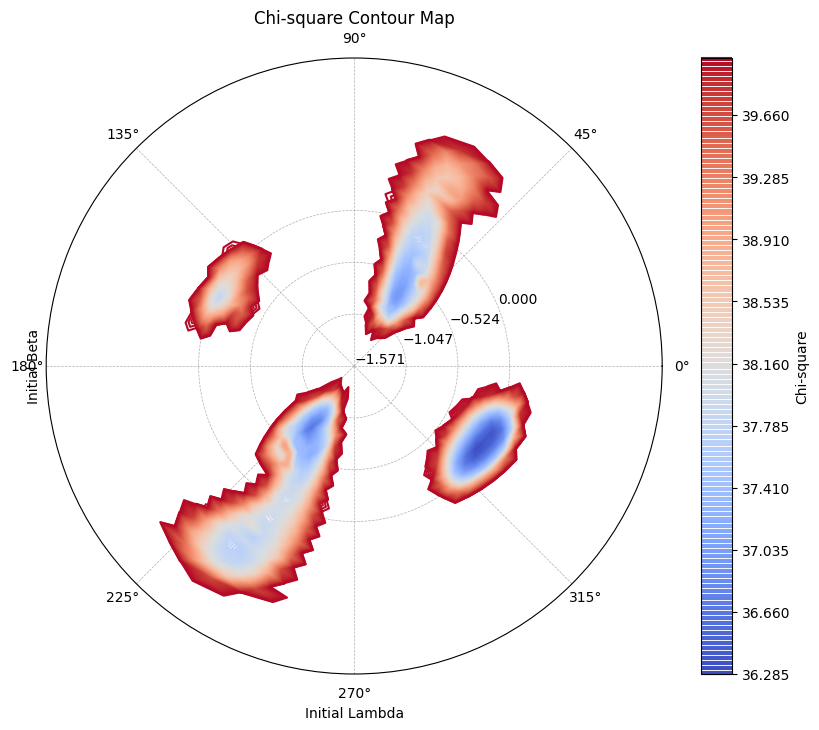

In [78]:
# Plot conturf map
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="polar")
plt.tricontour(np.deg2rad(xx - 0), np.deg2rad(yy), 
                np.where(Z_chi2 > 40, 40, Z_chi2), 
                levels=360, cmap="coolwarm")
plt.colorbar(label="Chi-square")
ax.set_rticks(np.linspace(0, -np.pi/2, 4))
plt.xlabel("Initial Lambda")
plt.ylabel("Initial Beta")
plt.title("Chi-square Contour Map")
plt.grid(lw=0.5, ls="--")
# ax.set_rlim(0, -np.pi/2)
plt.show()